# Analysis: PCA of Model Feature Spaces

### **Notebook Objective**

This notebook performs a deep-dive analysis into the internal feature spaces of the QRC and Classical ESN models. The goal is to understand the relationship between a model's performance (MSE) and the "effective dimensionality" of its internal state representation.

### **Process**
1.  **Load Data**: Import the main experiment results from the `.csv` file.
2.  **Iterate Profiles**: Loop through each data profile (e.g., Mackey-Glass, NARMA).
3.  **Analyze Best Classical Model**: For each profile, identify the best Classical ESN, regenerate its internal reservoir states, and calculate its effective dimensionality via PCA.
4.  **Analyze All QRC Models**: For each QRC hyperparameter combination, regenerate its quantum feature space and calculate its effective dimensionality. This is done in parallel for efficiency.
5.  **Visualize**: Create a scatter plot of Performance (MSE) vs. Effective Dimensionality for all QRC models, with the best Classical ESN's dimensionality shown as a reference line.

In [1]:
# === IMPORTS AND SETUP ===
import sys
import os

project_root = os.path.abspath('..')
if project_root not in sys.path:
    sys.path.insert(0, project_root)

# Import our custom modules
from src.data_generation import mackey_glass, generate_arma_data, generate_narma_data, create_io_pairs
from src.models import get_classical_reservoir_states # For classical analysis
from src.analysis import get_qrc_feature_space, calculate_effective_dimension # For QRC analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from joblib import Parallel, delayed

# Jupyter magic command for automatic reloading of external modules
%load_ext autoreload
%autoreload 2

print("Libraries and modules loaded successfully.")

Libraries and modules loaded successfully.


In [2]:
# === CONFIGURATION AND DATA LOADING ===

# Constants needed for regenerating data (must match the experiment notebook)
TRAIN_FRACTION = 0.6
SEED = 2025
RESULTS_FILENAME = '../data/results_comparative.csv'

# Data profiles config must be available to regenerate the time series
data_profiles_config = [
    {'name': 'Mackey_Glass_(tau=17)', 'generator': mackey_glass, 'params': {'tau': 17}},
    {'name': 'Mackey_Glass_(tau=30)', 'generator': mackey_glass, 'params': {'tau': 30}},
    {'name': 'Mackey_Glass_(tau=100)', 'generator': mackey_glass, 'params': {'tau': 100}},
    {'name': 'ARMA_1_2_stochastic', 'generator': generate_arma_data, 'params': {}},
    {'name': 'NARMA10_Chaotic', 'generator': generate_narma_data, 'params': {'order': 10}},
    {'name': 'NARMA5_Chaotic', 'generator': generate_narma_data, 'params': {'order': 5}}
]

# Load the results
try:
    results_df = pd.read_csv(RESULTS_FILENAME)
    print(f"Successfully loaded results from '{RESULTS_FILENAME}'.")
except FileNotFoundError:
    print(f"ERROR: The file '{RESULTS_FILENAME}' was not found. Please run the experiment notebook first.")
    results_df = pd.DataFrame()

Successfully loaded results from '../data/results_comparative.csv'.


DIAGNOSTYKA: Sprawdzanie zmiennych...
SUKCES: 'results_df' zawiera 1080 wierszy.
Znaleziono konfiguracje profili: 6 profili.

Przetwarzanie profilu: Mackey_Glass_(tau=17)
--> Znaleziono: 90 wynikow QRC oraz 90 wynikow ESN.
--> Regeneracja szeregu czasowego...
--> Analiza najlepszego modelu klasycznego...
--> Obliczanie wymiarow efektywnych dla QRC (to moze chwile potrwac)...


PCA Analysis:   0%|          | 0/90 [00:00<?, ?it/s]

--> Generowanie wykresu...
--> Wykres zapisano jako: ../reports/figures/Mackey_Glass_(tau=17)_pca_analysis_bw.png


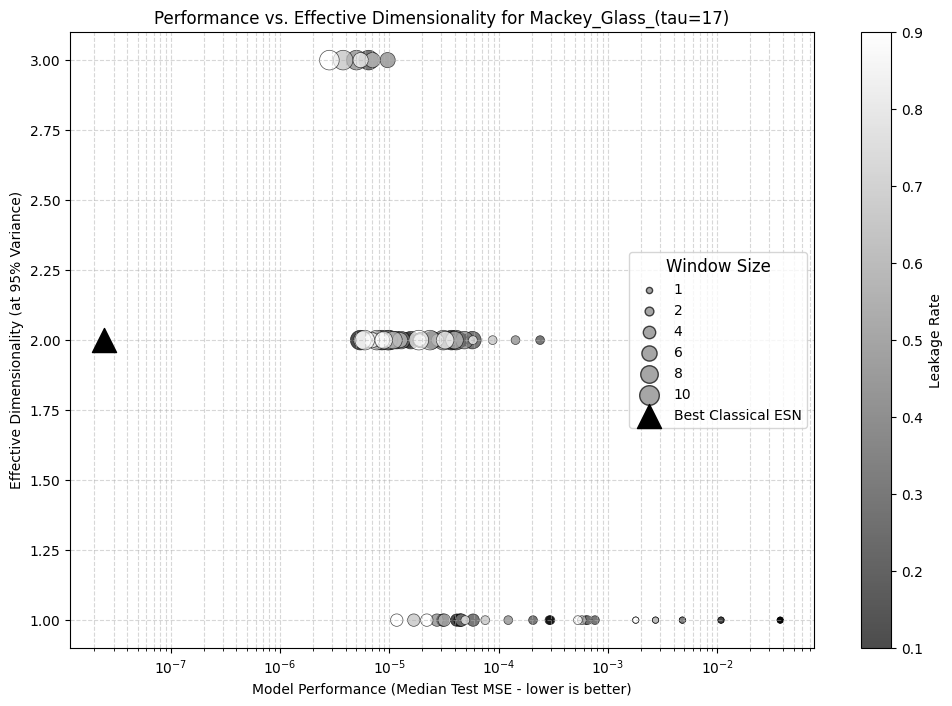


Przetwarzanie profilu: Mackey_Glass_(tau=30)
--> Znaleziono: 90 wynikow QRC oraz 90 wynikow ESN.
--> Regeneracja szeregu czasowego...
--> Analiza najlepszego modelu klasycznego...
--> Obliczanie wymiarow efektywnych dla QRC (to moze chwile potrwac)...


PCA Analysis:   0%|          | 0/90 [00:00<?, ?it/s]

--> Generowanie wykresu...
--> Wykres zapisano jako: ../reports/figures/Mackey_Glass_(tau=30)_pca_analysis_bw.png


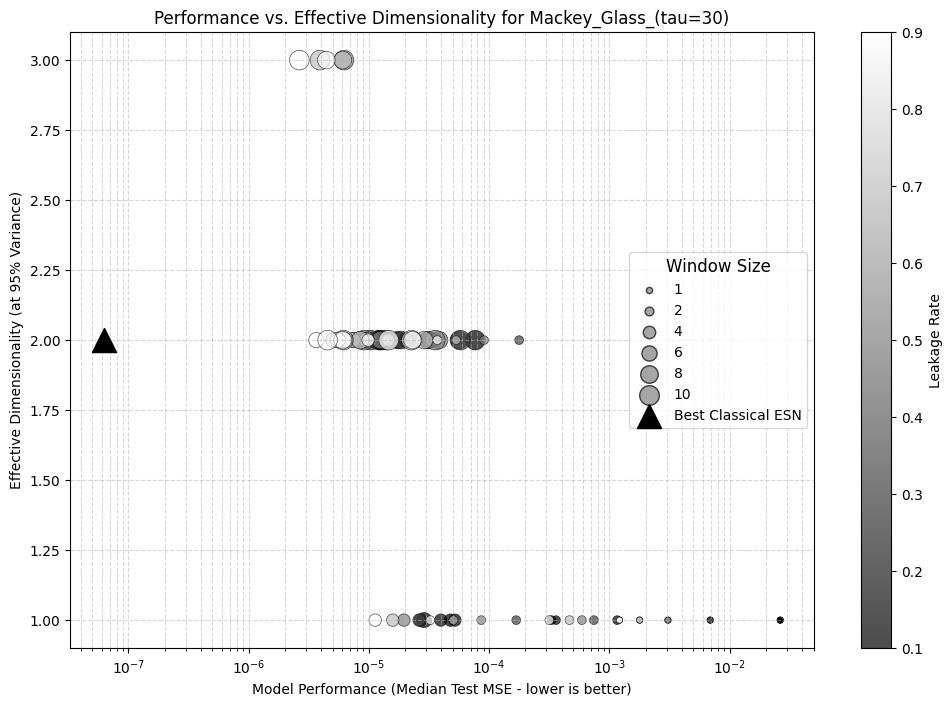


Przetwarzanie profilu: Mackey_Glass_(tau=100)
--> Znaleziono: 90 wynikow QRC oraz 90 wynikow ESN.
--> Regeneracja szeregu czasowego...
--> Analiza najlepszego modelu klasycznego...
--> Obliczanie wymiarow efektywnych dla QRC (to moze chwile potrwac)...


PCA Analysis:   0%|          | 0/90 [00:00<?, ?it/s]

--> Generowanie wykresu...
--> Wykres zapisano jako: ../reports/figures/Mackey_Glass_(tau=100)_pca_analysis_bw.png


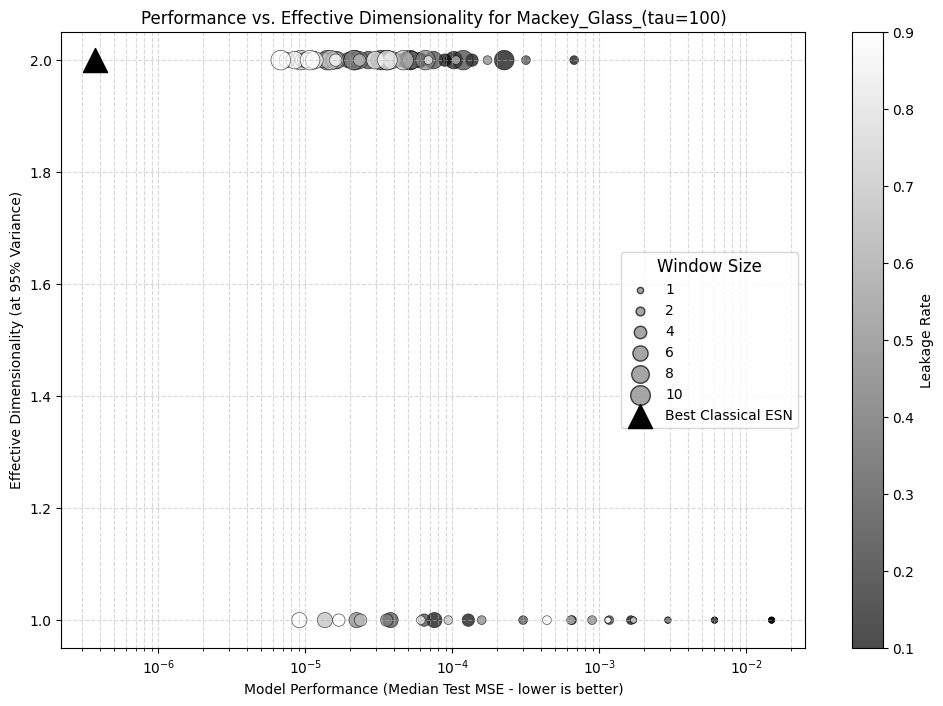


Przetwarzanie profilu: ARMA_1_2_stochastic
--> Znaleziono: 90 wynikow QRC oraz 90 wynikow ESN.
--> Regeneracja szeregu czasowego...
--> Analiza najlepszego modelu klasycznego...
--> Obliczanie wymiarow efektywnych dla QRC (to moze chwile potrwac)...


PCA Analysis:   0%|          | 0/90 [00:00<?, ?it/s]

--> Generowanie wykresu...
--> Wykres zapisano jako: ../reports/figures/ARMA_1_2_stochastic_pca_analysis_bw.png


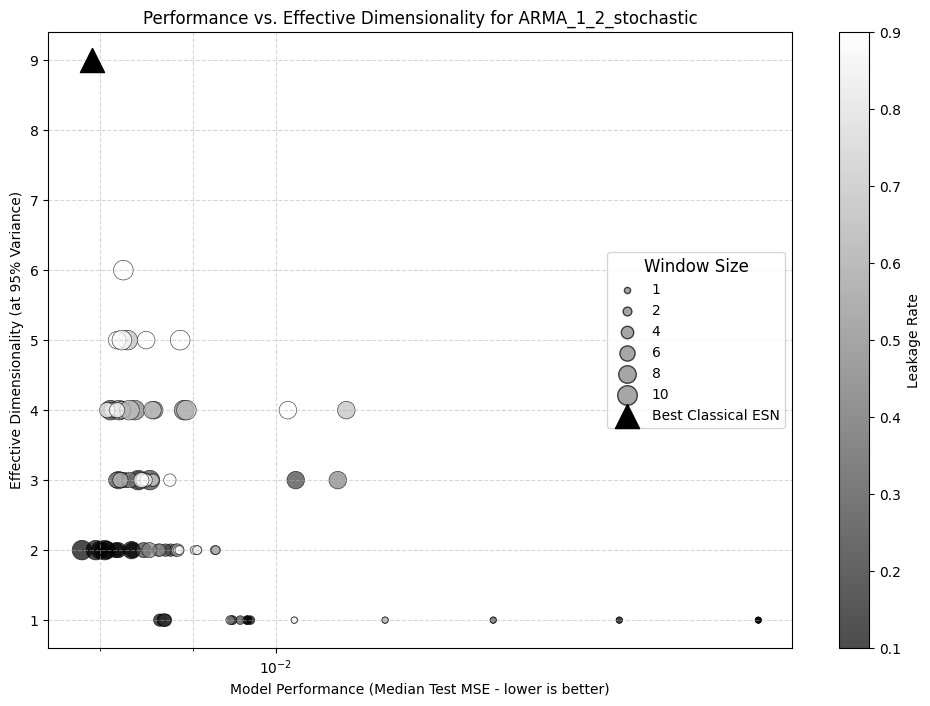


Przetwarzanie profilu: NARMA10_Chaotic
--> Znaleziono: 90 wynikow QRC oraz 90 wynikow ESN.
--> Regeneracja szeregu czasowego...
--> Analiza najlepszego modelu klasycznego...
--> Obliczanie wymiarow efektywnych dla QRC (to moze chwile potrwac)...


PCA Analysis:   0%|          | 0/90 [00:00<?, ?it/s]

--> Generowanie wykresu...
--> Wykres zapisano jako: ../reports/figures/NARMA10_Chaotic_pca_analysis_bw.png


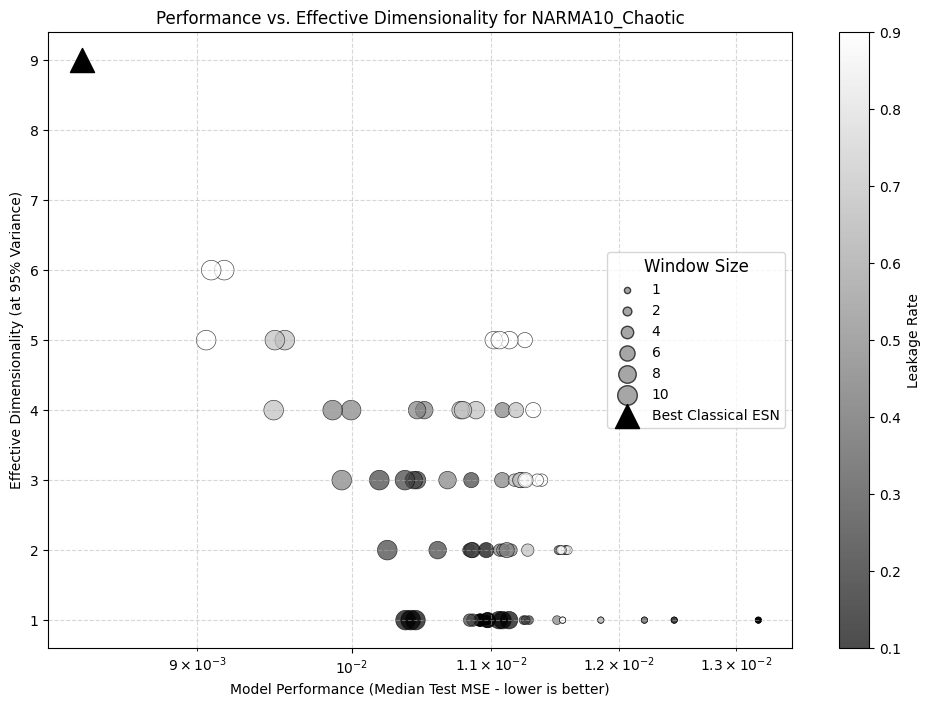


Przetwarzanie profilu: NARMA5_Chaotic
--> Znaleziono: 90 wynikow QRC oraz 90 wynikow ESN.
--> Regeneracja szeregu czasowego...
--> Analiza najlepszego modelu klasycznego...
--> Obliczanie wymiarow efektywnych dla QRC (to moze chwile potrwac)...


PCA Analysis:   0%|          | 0/90 [00:00<?, ?it/s]

--> Generowanie wykresu...
--> Wykres zapisano jako: ../reports/figures/NARMA5_Chaotic_pca_analysis_bw.png


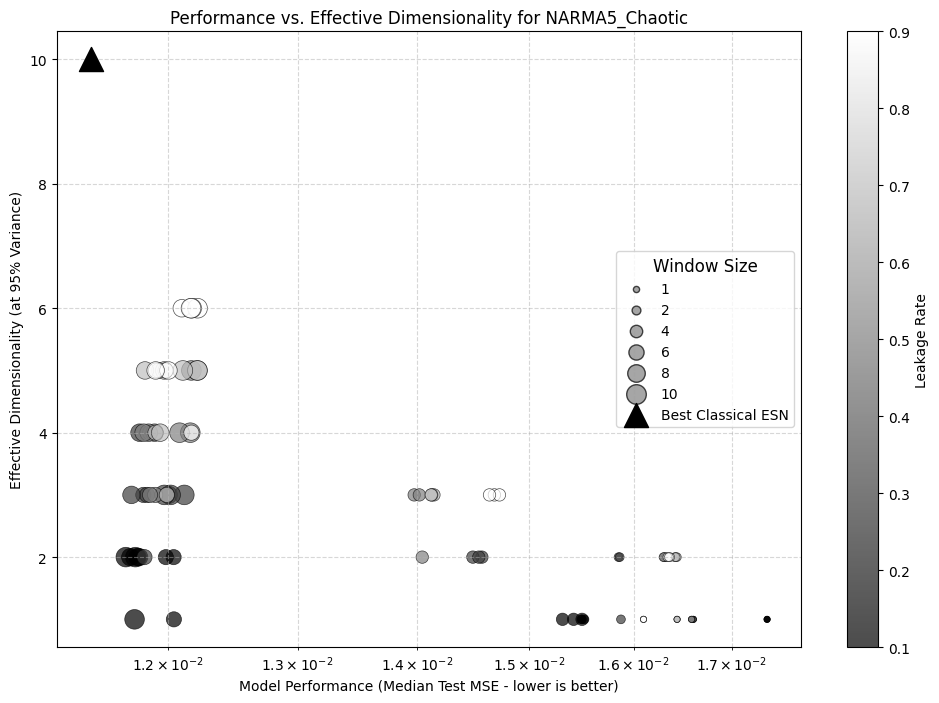


--- ZAKONCZONO ---


In [3]:
# === PCA ANALYSIS AND PLOTTING LOOP (DEBUG VERSION - BLACK & WHITE) ===
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from tqdm.notebook import tqdm

# Upewnijmy sie, ze funkcja pomocnicza jest zdefiniowana
def calculate_eff_dim_for_qrc_row(row, time_series, train_fraction, seed):
    """Wrapper function for joblib parallelization."""
    params_tuple = (
        row['leakage_rate'], row['lambda_reg'],
        int(row['window_size']), int(row['n_layers']), int(row['lag'])
    )
    features = get_qrc_feature_space(params_tuple, time_series, train_fraction, seed)
    return calculate_effective_dimension(features)

# --- DIAGNOSTYKA ---
print(f"DIAGNOSTYKA: Sprawdzanie zmiennych...")
if 'results_df' not in locals():
    print("BLAD KRYTYCZNY: Zmienna 'results_df' nie istnieje! Uruchom poprzednie komorki notebooka.")
elif results_df.empty:
    print("BLAD KRYTYCZNY: 'results_df' jest puste! Sprawdz czy plik CSV zostal wczytany.")
else:
    print(f"SUKCES: 'results_df' zawiera {len(results_df)} wierszy.")

if 'data_profile_config' in locals():
    profiles_to_run = data_profile_config
    print(f"Znaleziono konfiguracje profili: {len(profiles_to_run)} profili.")
elif 'data_profiles_config' in locals():
    profiles_to_run = data_profiles_config
    print(f"Znaleziono konfiguracje profili: {len(profiles_to_run)} profili.")
else:
    try:
        profiles_to_run = data_profiles_config
    except NameError:
        print("BLAD: Nie znaleziono listy 'data_profiles_config'.")
        profiles_to_run = []

# --- GLOWNA PETLA ---
if not results_df.empty and len(profiles_to_run) > 0:
    for profile_config in profiles_to_run:
        profile_name = profile_config['name']
        print(f"\n{'='*60}")
        print(f"Przetwarzanie profilu: {profile_name}")

        # Filtrowanie danych
        profile_df = results_df[results_df['data_profile'] == profile_name]
        qrc_df = profile_df[profile_df['model_type'] == 'QRC'].copy().dropna(subset=['median_val_mse'])
        classical_df = profile_df[profile_df['model_type'] == 'Classical_ESN'].copy().dropna(subset=['median_val_mse'])

        print(f"--> Znaleziono: {len(qrc_df)} wynikow QRC oraz {len(classical_df)} wynikow ESN.")

        if qrc_df.empty or classical_df.empty:
            print(f"--> POMIJAM: Brak wystarczajacych danych dla '{profile_name}'.")
            continue

        # Regeneracja szeregu czasowego
        print("--> Regeneracja szeregu czasowego...")
        time_series = profile_config['generator'](**profile_config['params'])

        # 1. Analiza klasycznego ESN (selekcja po val MSE, raport po test MSE)
        print("--> Analiza najlepszego modelu klasycznego...")
        try:
            best_classical_row = classical_df.loc[classical_df['median_val_mse'].idxmin()]
            classical_win_size = int(best_classical_row.get('window_size', 10))

            train_inputs_classical, _ = create_io_pairs(time_series[:int(len(time_series) * TRAIN_FRACTION)], classical_win_size)

            classical_states = get_classical_reservoir_states(
                train_inputs=train_inputs_classical,
                reservoir_size=int(best_classical_row['reservoir_size']),
                leakage_rate=best_classical_row['leakage_rate'],
                spectral_radius=best_classical_row['spectral_radius'],
                sparsity=best_classical_row['sparsity'],
                seed=SEED,
                input_dim=classical_win_size
            )

            eff_dim_classical = calculate_effective_dimension(classical_states)
            mse_classical = best_classical_row['median_test_mse']
        except Exception as e:
            print(f"BLAD przy analizie ESN: {e}")
            continue

        # 2. Analiza QRC (Rownolegla)
        print("--> Obliczanie wymiarow efektywnych dla QRC (to moze chwile potrwac)...")
        effective_dims = Parallel(n_jobs=-1)(
            delayed(calculate_eff_dim_for_qrc_row)(row, time_series, TRAIN_FRACTION, SEED)
            for _, row in tqdm(qrc_df.iterrows(), total=qrc_df.shape[0], desc=f"PCA Analysis")
        )
        qrc_df['effective_dim'] = effective_dims

        # 3. Rysowanie wykresu (Czarno-bialy)
        print("--> Generowanie wykresu...")
        try:
            plt.figure(figsize=(12, 8))

            # QRC Points — x-axis is test MSE (final reported metric)
            scatter = plt.scatter(
                qrc_df['median_test_mse'],
                qrc_df['effective_dim'],
                c=qrc_df['leakage_rate'],
                cmap='gray',
                alpha=0.7,
                s=qrc_df['window_size']*20,
                edgecolors='black',
                linewidth=0.5
            )

            # Best Classical ESN
            plt.scatter(
                mse_classical,
                eff_dim_classical,
                marker='^',
                s=300,
                c='black',
                edgecolors='black',
                label='Best Classical ESN',
                zorder=10
            )

            plt.colorbar(scatter, label='Leakage Rate')

            plt.title(f'Performance vs. Effective Dimensionality for {profile_name}')
            plt.xlabel('Model Performance (Median Test MSE - lower is better)')
            plt.ylabel('Effective Dimensionality (at 95% Variance)')
            plt.xscale('log')
            plt.grid(True, which="both", ls="--", alpha=0.5)

            # Legenda
            size_handles = [plt.scatter([], [], s=size*20, label=f'{int(size)}',
                                        c='gray', alpha=0.7, edgecolors='black')
                            for size in sorted(qrc_df['window_size'].unique())]

            classical_handle = plt.scatter([], [], s=300, marker='^', c='black',
                                           edgecolors='black', label='Best Classical ESN')

            all_handles = size_handles + [classical_handle]
            plt.legend(handles=all_handles, title='Window Size', loc='center right', fontsize=10, title_fontsize=12)

            # Zapis i wyswietlenie
            filename = f"../reports/figures/{profile_name}_pca_analysis_bw.png"
            plt.savefig(filename, dpi=300)
            print(f"--> Wykres zapisano jako: {filename}")
            plt.show()

        except Exception as e:
            print(f"BLAD podczas rysowania: {e}")

print("\n--- ZAKONCZONO ---")